In [ ]:
# necessary imports
import os
import re
import random
import datetime
from datetime import timedelta

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from keras.utils import to_categorical
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    precision_score, recall_score, f1_score, auc,
    precision_recall_curve)

import data_preprocessing
import data_models

## Read data and assing age groups

In [ ]:
# Define schema override
schema = {
    "Age": pl.Utf8,
}

# Read CSV with schema
raw_data = pl.read_csv("Data/SDBII_15.csv", schema_overrides=schema)

raw_data = raw_data.with_columns(
    pl.col("ts").str.to_datetime()
)

raw_data_sorted = raw_data.sort(["PtID", "ts"])
raw_data_sorted = raw_data_sorted.unique(subset=["PtID", "ts"], keep="first")

In [ ]:
df_age = data_preprocessing.convert_age_strings(raw_data_sorted)
df_age = data_preprocessing.assign_age_group_from_string_ranges(df_age)

## extract subjects with more data as test subjects

In [4]:
counts = (
    df_age
    .group_by(["AgeGroup", "PtID"])
    .agg(pl.count("GlucoseCGM").alias("count"))
)

top5_per_age = (
    counts
    .sort(["AgeGroup", "count"], descending=[False, True])
    .with_columns(
        pl.col("count")
        .rank("dense", descending=True)
        .over("AgeGroup")
        .alias("rank")
    )
    .filter(pl.col("rank") <= 10)
)

print(top5_per_age)

shape: (40, 4)
┌──────────┬──────────────────────┬───────┬──────┐
│ AgeGroup ┆ PtID                 ┆ count ┆ rank │
│ ---      ┆ ---                  ┆ ---   ┆ ---  │
│ i32      ┆ str                  ┆ u32   ┆ u32  │
╞══════════╪══════════════════════╪═══════╪══════╡
│ 0        ┆ 73.0_PEDAP           ┆ 39546 ┆ 1    │
│ 0        ┆ 53.0_PEDAP           ┆ 36683 ┆ 2    │
│ 0        ┆ 38.0_PEDAP           ┆ 36331 ┆ 3    │
│ 0        ┆ 87.0_PEDAP           ┆ 36266 ┆ 4    │
│ 0        ┆ 28.0_SENCE           ┆ 36101 ┆ 5    │
│ …        ┆ …                    ┆ …     ┆ …    │
│ 3        ┆ 91.0_WISDM           ┆ 35012 ┆ 6    │
│ 3        ┆ 205.0_WISDM          ┆ 34913 ┆ 7    │
│ 3        ┆ 165.0_WISDM          ┆ 34697 ┆ 8    │
│ 3        ┆ LIB193307_T1DGranada ┆ 34552 ┆ 9    │
│ 3        ┆ 47.0_WISDM           ┆ 34549 ┆ 10   │
└──────────┴──────────────────────┴───────┴──────┘


In [5]:
top5_per_age["count"].sum()

2371889

In [6]:
# Convert top5_per_age into dictionary {AgeGroup: [PtIDs]}
result_dict = (
    top5_per_age
    .group_by("AgeGroup")
    .agg(pl.col("PtID").alias("PtIDs"))
    .to_dict(as_series=False)
)


# Collect the list of ids and map them per agegroup
age_to_ids = dict(zip(result_dict["AgeGroup"], result_dict["PtIDs"]))

# Store only the Patients IDs in a numpy array
subjects = list(age_to_ids.values())
subjects = np.array(subjects)

In [7]:
## Extract the top 10 subjects with most data for each age group and store them separately
children = df_age.filter(pl.col("PtID").is_in(subjects[0]) & (pl.col("AgeGroup") ==0))
teenagers = df_age.filter(pl.col("PtID").is_in(subjects[1])& (pl.col("AgeGroup") ==1))
adults = df_age.filter(pl.col("PtID").is_in(subjects[2])& (pl.col("AgeGroup") ==2))
seniors = df_age.filter(pl.col("PtID").is_in(subjects[3])& (pl.col("AgeGroup") ==3))

# Remove the Subjects which are in the test data from the train data
df_filtered_age = df_age.filter(~(pl.col("PtID").is_in(subjects[0])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[1])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[2])))
df_filtered_age = df_filtered_age.filter(~(pl.col("PtID").is_in(subjects[3])))

## Preprocessing

In [ ]:
# removes outliers 
cleaned_static = data_preprocessing.remove_outliers_polars(df_filtered_age, value="GlucoseCGM")

data_cleanedpd = cleaned_static.to_pandas()
# data should be sorted by time before interpolation
data_cleanedpd = data_cleanedpd.sort_values(by=["PtID", "ts"]).reset_index(drop=True)

# linear interpolation is used for gaps which are less than 30 minute (6 consecuitve datapoints)
data_cleanedpd["GlucoseCGM"] = data_cleanedpd.groupby("PtID")["GlucoseCGM"].transform(
    lambda x: data_preprocessing.gap_limited_interpolation(x, limit=2)
)

# stineman interpolation for values between 30 adn 120 minutes
df_interpolated_stine = data_cleanedpd.groupby("PtID", group_keys=False).apply(
    lambda x: data_preprocessing.interpolate_stineman_group(x, timestamp = "ts", value = "GlucoseCGM", llimit=2, ulimit=8))
df_interpolated_stine = df_interpolated_stine.sort_index()

df_interpolated_stine = df_interpolated_stine[["ts", "GlucoseCGM", "PtID",	"AgeGroup"]]

## class assignment

In [9]:
classes_df = df_interpolated_stine.sort_values(by=["PtID", "ts"]).reset_index(drop=True)
                                                          
# initially all classes are assigned a class -1
classes_df["Class1"] = -1

# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class1"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 20, 1, col_name = "Class1")) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 20, 50, 2, col_name = "Class1")) # 20-45 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 50, 125, 3, col_name = "Class1"))  # 50-120 min
classes_df.loc[classes_df["Class1"] == -1, "Class1"] = 4

# sorts the glucose values by patient id and timestamps
df_sorted1 = classes_df.sort_values(by=["PtID", "ts"])
# reindexes based on the sorted dataset
df_sorted1 = df_sorted1.reset_index(drop=True)
# nneu noch mehr neu
df_sorted1["Class1"].value_counts()

Class1
4    71762315
3     1617479
0     1294444
2      716564
1      383828
Name: count, dtype: int64

## normalization

In [10]:
df_scaled = data_preprocessing.normalize_data(df_sorted1, "GlucoseCGM")

In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

import pandas as pd
from sklearn.model_selection import train_test_split

# df = your dataframe
# Assumes patient id column is named "PtID"
id_col = "PtID"

# 1) extract all unique patient IDs
ptids = df_scaled[id_col].dropna().unique()

# 2) split IDs into train/test (change test_size/random_state as needed)
train_ids, test_ids = train_test_split(
    ptids,
    test_size=0.9,
    random_state=42,
    shuffle=True
)

# 3) split the actual dataframe by those IDs
train_df = df_scaled[df_scaled[id_col].isin(train_ids)].copy()
test_df  = df_scaled[df_scaled[id_col].isin(test_ids)].copy()

# (optional) sanity checks
assert set(train_df[id_col].unique()).isdisjoint(set(test_df[id_col].unique()))
print(len(train_ids), len(test_ids), train_df.shape, test_df.shape)
df_scaled = {age: group for age, group in train_df.groupby("AgeGroup")}

245 2214 (7129528, 5) (68645102, 5)


In [ ]:
from sklearn.model_selection import train_test_split
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

def data_initialization(results, convert_to_shape = 9, seed = 42):

    X_data_train = []
    Y_data_train = []
    all_subjects_X = []
    all_subjects_Y = []

    for age, (X_data, Y_data) in results.items():
        print(f"Splitting data for age group {age}...")

        X_data_train.append(X_data) 
        Y_data_train.append(Y_data)

    for group in X_data_train:        # each age group
        for subjects in group:    # list of subjects in that group
            for subj in subjects:
                # subj is a list of arrays → combine into one array per subject
                subj_concat = np.concatenate(subj, axis=0)
                flattened_data = subj_concat.reshape(-1,convert_to_shape,1)
                all_subjects_X.append(flattened_data)

    print(f"Total subjects: {len(all_subjects_X)}")
    print(f"Shape of first subject data: {all_subjects_X[0].shape}")



    for group in Y_data_train:        # each age group
        for subjects in group:    # list of subjects in that group
            for subj in subjects:
                # subj is a list of arrays → combine into one array per subject
                subj_concat = np.concatenate(subj, axis=0)
                all_subjects_Y.append(subj_concat)

    print(f"Total subjects: {len(all_subjects_Y)}")
    print(f"Shape of first subject data: {all_subjects_Y[0].shape}")


    idx = np.arange(0, len(all_subjects_X))
    train_idx, test_idx = train_test_split(idx, test_size=0.3, shuffle=True, random_state=seed)

    # extracts the selected subjects for training for the X and Y folds
    X_train_fold = [all_subjects_X[i] for i in train_idx]
    Y_train_fold = [all_subjects_Y[i] for i in train_idx]
    # extracts the selected subjects for testing for the X and Y folds
    X_test_fold = [all_subjects_X[i] for i in test_idx]
    Y_test_fold = [all_subjects_Y[i] for i in test_idx]

    # flattens the arrays of single subjects into one array of shape (X,25,2)
    X_train_fold = np.concatenate(X_train_fold, axis=0)
    Y_train_fold = np.concatenate(Y_train_fold, axis=0)
    X_test_fold = np.concatenate(X_test_fold, axis=0)
    Y_test_fold= np.concatenate(Y_test_fold, axis=0)

    return X_train_fold, Y_train_fold, X_test_fold, Y_test_fold 

## Ablation Studies with Class1

## 30 min ISL

2026-03-04 19:32:17.115481: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 19:32:17.115504: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2560, 3, 1)
Total subjects: 248
Shape of first subject data: (2560,)
Alpha weights: [0.55855286 1.9304473  1.0404501  0.47054964]


2026-03-04 19:33:43.573953: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3558 [..............................] - ETA: 12:24

2026-03-04 19:40:41.953852: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3558/3558 [==============================] - 10s 3ms/step


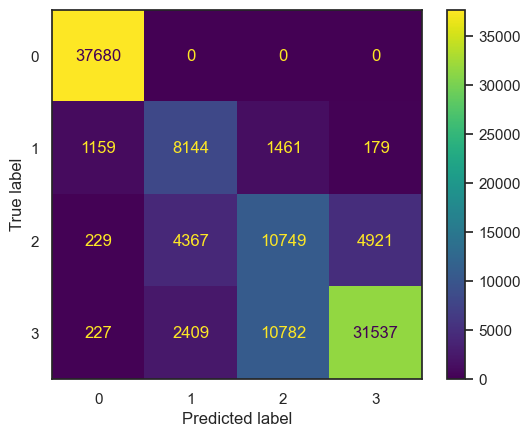

              precision    recall  f1-score   support

           0     0.9589    1.0000    0.9790     37680
           1     0.5458    0.7442    0.6298     10943
           2     0.4675    0.5304    0.4970     20266
           3     0.8608    0.7015    0.7730     44955

    accuracy                         0.7740    113844
   macro avg     0.7083    0.7440    0.7197    113844
weighted avg     0.7930    0.7740    0.7783    113844

Class PR AUC: [[0.9999761377098932, 0.6512719399897532, 0.45494529904984793, 0.8874615477996383]]
Mac PR AUC: ([0.7484137311372832])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2560, 3, 1)
Total subjects: 248
Shape of first subject data: (2560,)
Alpha weights: [0.55181384 1.9321035  1.0435138  0.47256878]


2026-03-04 19:40:54.589090: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3594 [..............................] - ETA: 12:15

2026-03-04 19:47:48.374658: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3594/3594 [==============================] - 10s 3ms/step


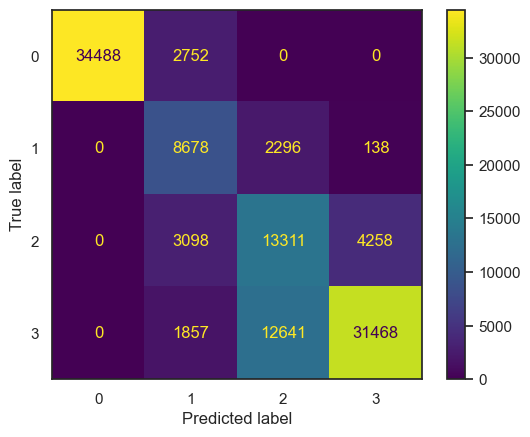

              precision    recall  f1-score   support

           0     1.0000    0.9261    0.9616     37240
           1     0.5296    0.7810    0.6312     11112
           2     0.4712    0.6441    0.5443     20667
           3     0.8774    0.6846    0.7691     45966

    accuracy                         0.7648    114985
   macro avg     0.7196    0.7589    0.7265    114985
weighted avg     0.8105    0.7648    0.7777    114985

Class PR AUC: [[0.9999761377098932, 0.6512719399897532, 0.45494529904984793, 0.8874615477996383], [0.999989722606633, 0.6592018574176421, 0.4832058584602606, 0.8963215166927978]]
Mac PR AUC: ([0.7484137311372832, 0.7596797387943334])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2560, 3, 1)
Total subjects: 248
Shape of first subject data: (2560,)
Alpha weights: [0.5535711 1.9319304 1.0423377 0.4721607]


2026-03-04 19:48:01.042133: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3448 [..............................] - ETA: 11:50

2026-03-04 19:54:59.049403: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3448/3448 [==============================] - 10s 3ms/step


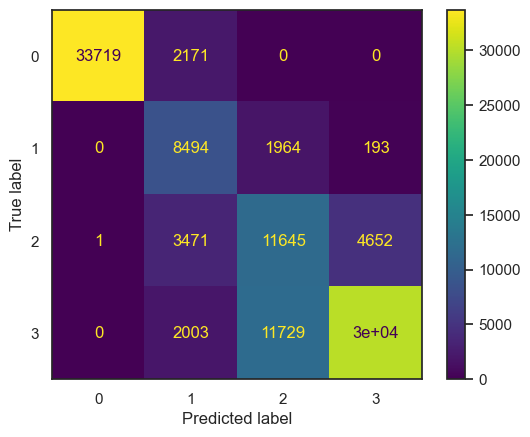

              precision    recall  f1-score   support

           0     1.0000    0.9395    0.9688     35890
           1     0.5263    0.7975    0.6341     10651
           2     0.4596    0.5891    0.5163     19769
           3     0.8620    0.6880    0.7652     44008

    accuracy                         0.7626    110318
   macro avg     0.7120    0.7535    0.7211    110318
weighted avg     0.8024    0.7626    0.7742    110318

Class PR AUC: [[0.9999761377098932, 0.6512719399897532, 0.45494529904984793, 0.8874615477996383], [0.999989722606633, 0.6592018574176421, 0.4832058584602606, 0.8963215166927978], [0.9999864359881374, 0.7167013508737105, 0.458182155923243, 0.8886182537572096]]
Mac PR AUC: ([0.7484137311372832, 0.7596797387943334, 0.7658720491355752])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=3, hours=30, modus="m")
    results[age] = (X_data, Y_data)


for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 3, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/15_min_Ablation_Class1_30min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 45 min

2026-03-04 19:08:11.413430: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-04 19:08:11.418654: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-04 19:08:11.418668: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-03-04 19:08:11.418746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 19:08:11.418773: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2551, 4, 1)
Total subjects: 248
Shape of first subject data: (2551,)


2026-03-04 19:09:37.760153: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 19:09:37.760181: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Alpha weights: [0.5599627  1.9297211  1.0394404  0.47087598]


2026-03-04 19:09:38.646103: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3526 [..............................] - ETA: 13:52

2026-03-04 19:16:33.229616: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3526/3526 [==============================] - 9s 2ms/step


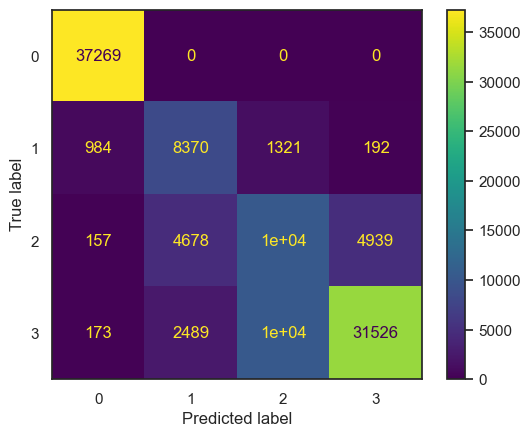

              precision    recall  f1-score   support

           0     0.9659    1.0000    0.9827     37269
           1     0.5387    0.7702    0.6340     10867
           2     0.4697    0.5144    0.4910     20129
           3     0.8600    0.7075    0.7763     44559

    accuracy                         0.7757    112824
   macro avg     0.7086    0.7480    0.7210    112824
weighted avg     0.7944    0.7757    0.7799    112824

Class PR AUC: [[0.9999489691162864, 0.6774353993932218, 0.4486115953358394, 0.8897595231428767]]
Mac PR AUC: ([0.7539388717470561])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2551, 4, 1)
Total subjects: 248
Shape of first subject data: (2551,)
Alpha weights: [0.5531689  1.931578   1.0421764  0.47307685]


2026-03-04 19:16:44.840441: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3565 [..............................] - ETA: 11:47

2026-03-04 19:23:38.150550: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3565/3565 [==============================] - 9s 2ms/step


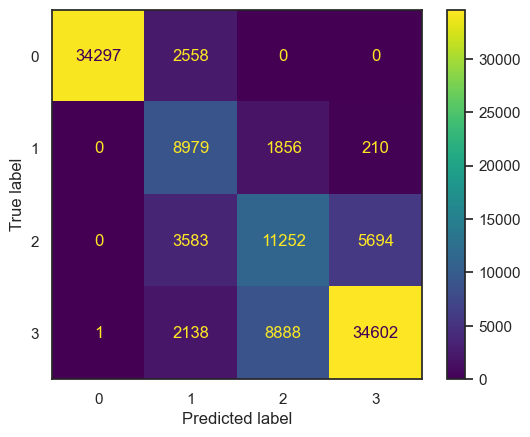

              precision    recall  f1-score   support

           0     1.0000    0.9306    0.9640     36855
           1     0.5203    0.8129    0.6345     11045
           2     0.5115    0.5481    0.5292     20529
           3     0.8542    0.7583    0.8034     45629

    accuracy                         0.7814    114058
   macro avg     0.7215    0.7625    0.7328    114058
weighted avg     0.8073    0.7814    0.7896    114058

Class PR AUC: [[0.9999489691162864, 0.6774353993932218, 0.4486115953358394, 0.8897595231428767], [0.9999955858690928, 0.7097298962334826, 0.505616415589893, 0.898713446078865]]
Mac PR AUC: ([0.7539388717470561, 0.7785138359428334])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2551, 4, 1)
Total subjects: 248
Shape of first subject data: (2551,)
Alpha weights: [0.55512965 1.9305733  1.04177    0.47252715]


2026-03-04 19:23:49.554917: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3421 [..............................] - ETA: 12:54

2026-03-04 19:30:48.196058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3421/3421 [==============================] - 9s 2ms/step


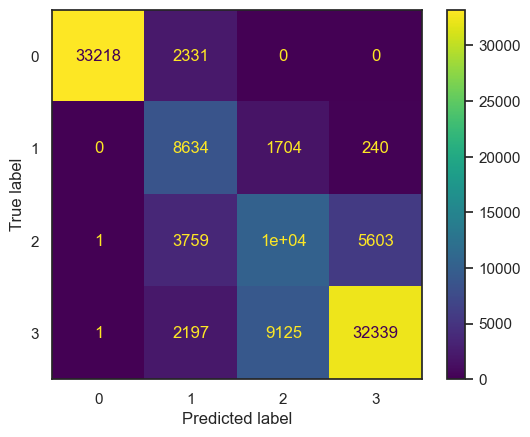

              precision    recall  f1-score   support

           0     0.9999    0.9344    0.9661     35549
           1     0.5103    0.8162    0.6280     10578
           2     0.4876    0.5240    0.5051     19669
           3     0.8470    0.7407    0.7903     43662

    accuracy                         0.7720    109458
   macro avg     0.7112    0.7538    0.7224    109458
weighted avg     0.7995    0.7720    0.7804    109458

Class PR AUC: [[0.9999489691162864, 0.6774353993932218, 0.4486115953358394, 0.8897595231428767], [0.9999955858690928, 0.7097298962334826, 0.505616415589893, 0.898713446078865], [0.9999819709944935, 0.7105455441589439, 0.4764220448997726, 0.8904265305537764]]
Mac PR AUC: ([0.7539388717470561, 0.7785138359428334, 0.7693440226517465])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=4, hours=45, modus="m")
    results[age] = (X_data, Y_data)


for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 4, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/15_min_Ablation_Class1_45min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 1 hour

2026-03-04 19:55:11.737220: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 19:55:11.737257: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 0...
Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2542, 5, 1)
Total subjects: 248
Shape of first subject data: (2542,)
Alpha weights: [0.5607147  1.9286096  1.0393056  0.47136998]


2026-03-04 19:56:37.697302: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3496 [..............................] - ETA: 12:21

2026-03-04 20:03:41.806328: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3496/3496 [==============================] - 8s 2ms/step


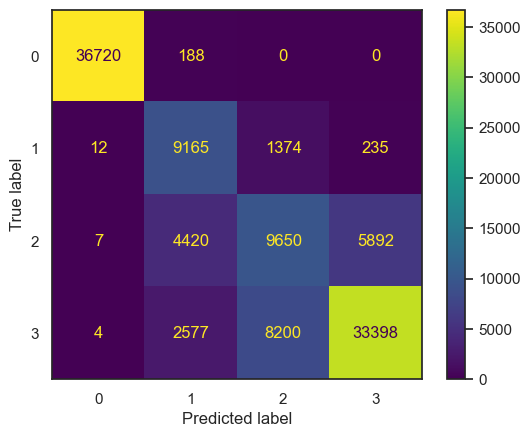

              precision    recall  f1-score   support

           0     0.9994    0.9949    0.9971     36908
           1     0.5606    0.8497    0.6755     10786
           2     0.5020    0.4832    0.4924     19969
           3     0.8450    0.7560    0.7980     44179

    accuracy                         0.7952    111842
   macro avg     0.7267    0.7710    0.7408    111842
weighted avg     0.8073    0.7952    0.7973    111842

Class PR AUC: [[0.9999808482402281, 0.7393233066290621, 0.47974480528537794, 0.8903839941859627]]
Mac PR AUC: ([0.7773582385851577])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2542, 5, 1)
Total subjects: 248
Shape of first subject data: (2542,)
Alpha weights: [0.5539191 1.9304352 1.0420413 0.4736042]


2026-03-04 20:03:52.724211: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3537 [..............................] - ETA: 12:44

2026-03-04 20:10:48.053591: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3537/3537 [==============================] - 8s 2ms/step


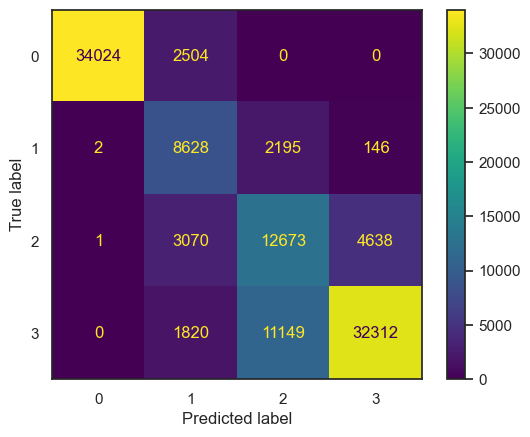

              precision    recall  f1-score   support

           0     0.9999    0.9314    0.9645     36528
           1     0.5385    0.7864    0.6393     10971
           2     0.4871    0.6218    0.5463     20382
           3     0.8710    0.7136    0.7845     45281

    accuracy                         0.7744    113162
   macro avg     0.7241    0.7633    0.7336    113162
weighted avg     0.8112    0.7744    0.7856    113162

Class PR AUC: [[0.9999808482402281, 0.7393233066290621, 0.47974480528537794, 0.8903839941859627], [0.9999589563014536, 0.7111142134331683, 0.5057691362777682, 0.8987980647154921]]
Mac PR AUC: ([0.7773582385851577, 0.7789100926819705])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2542, 5, 1)
Total subjects: 248
Shape of first subject data: (2542,)
Alpha weights: [0.5557438 1.9298984 1.0416478 0.4727099]


2026-03-04 20:10:58.994723: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3395 [..............................] - ETA: 11:41

2026-03-04 20:18:15.902293: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3395/3395 [==============================] - 9s 3ms/step


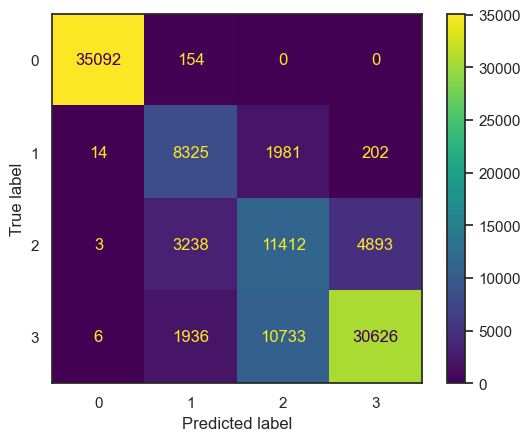

              precision    recall  f1-score   support

           0     0.9993    0.9956    0.9975     35246
           1     0.6098    0.7912    0.6887     10522
           2     0.4730    0.5839    0.5226     19546
           3     0.8574    0.7073    0.7751     43301

    accuracy                         0.7868    108615
   macro avg     0.7349    0.7695    0.7460    108615
weighted avg     0.8103    0.7868    0.7935    108615

Class PR AUC: [[0.9999808482402281, 0.7393233066290621, 0.47974480528537794, 0.8903839941859627], [0.9999589563014536, 0.7111142134331683, 0.5057691362777682, 0.8987980647154921], [0.9999743015201833, 0.7293203370262158, 0.46071368427145326, 0.8900478778349917]]
Mac PR AUC: ([0.7773582385851577, 0.7789100926819705, 0.7700140501632111])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=5, hours=1, modus="h")
    results[age] = (X_data, Y_data)


for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 5, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/15_min_Ablation_Class1_60min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 90 min

Processing age group 0...

2026-03-04 20:18:27.844005: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 20:18:27.844054: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2524, 7, 1)
Total subjects: 248
Shape of first subject data: (2524,)
Alpha weights: [0.5609511  1.926756   1.0404632  0.47182956]


2026-03-04 20:19:53.622369: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-03-04 20:27:17.550853: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3435/3435 [==============================] - 9s 2ms/step


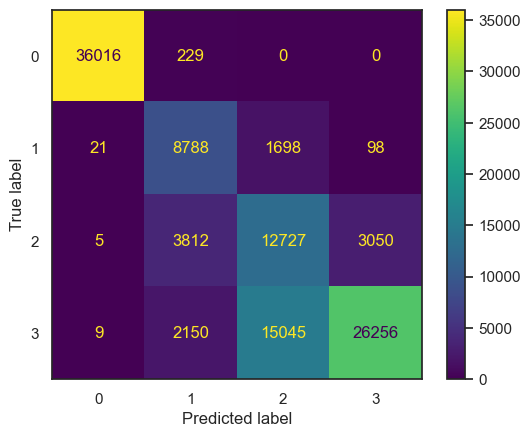

              precision    recall  f1-score   support

           0     0.9990    0.9937    0.9963     36245
           1     0.5867    0.8287    0.6870     10605
           2     0.4319    0.6495    0.5188     19594
           3     0.8929    0.6041    0.7207     43460

    accuracy                         0.7624    109904
   macro avg     0.7276    0.7690    0.7307    109904
weighted avg     0.8162    0.7624    0.7724    109904

Class PR AUC: [[0.999961542295839, 0.7356530859272282, 0.45305032740467477, 0.8910200028882479]]
Mac PR AUC: ([0.7699212396289975])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2524, 7, 1)
Total subjects: 248
Shape of first subject data: (2524,)
Alpha weights: [0.5538836  1.9281763  1.0442293  0.47371098]


2026-03-04 20:27:28.990633: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3482 [..............................] - ETA: 13:02

2026-03-04 20:34:37.323084: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3482/3482 [==============================] - 9s 2ms/step


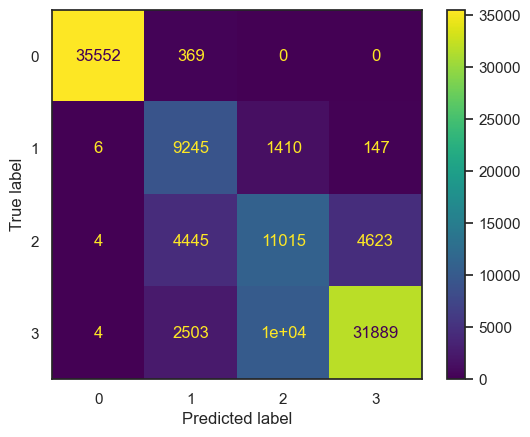

              precision    recall  f1-score   support

           0     0.9996    0.9897    0.9946     35921
           1     0.5582    0.8554    0.6756     10808
           2     0.4872    0.5484    0.5160     20087
           3     0.8699    0.7153    0.7851     44580

    accuracy                         0.7873    111396
   macro avg     0.7287    0.7772    0.7428    111396
weighted avg     0.8125    0.7873    0.7935    111396

Class PR AUC: [[0.999961542295839, 0.7356530859272282, 0.45305032740467477, 0.8910200028882479], [0.9999707579457371, 0.7450337100842148, 0.4839606428100033, 0.8983659257714012]]
Mac PR AUC: ([0.7699212396289975, 0.7818327591528391])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2524, 7, 1)
Total subjects: 248
Shape of first subject data: (2524,)
Alpha weights: [0.55603397 1.9285113  1.0432037  0.4722511 ]


2026-03-04 20:34:48.806697: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3342 [..............................] - ETA: 12:12

2026-03-04 20:41:58.421818: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3342/3342 [==============================] - 8s 2ms/step


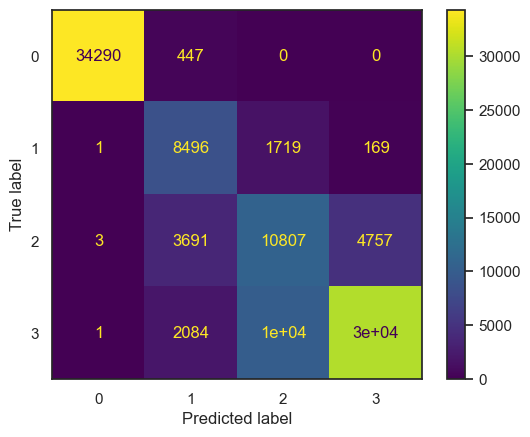

              precision    recall  f1-score   support

           0     0.9999    0.9871    0.9935     34737
           1     0.5773    0.8181    0.6769     10385
           2     0.4773    0.5612    0.5158     19258
           3     0.8604    0.7133    0.7800     42560

    accuracy                         0.7850    106940
   macro avg     0.7287    0.7699    0.7415    106940
weighted avg     0.8092    0.7850    0.7917    106940

Class PR AUC: [[0.999961542295839, 0.7356530859272282, 0.45305032740467477, 0.8910200028882479], [0.9999707579457371, 0.7450337100842148, 0.4839606428100033, 0.8983659257714012], [0.9999906007308981, 0.7245404042676495, 0.4686892902495813, 0.8920566931877575]]
Mac PR AUC: ([0.7699212396289975, 0.7818327591528391, 0.7713192471089716])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=7, hours=90, modus="m")
    results[age] = (X_data, Y_data)


for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 7, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/15_min_Ablation_Class1_90min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## 2 hours

Processing age group 0...


2026-03-04 20:42:09.129976: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 20:42:09.130018: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Processing age group 1...
Processing age group 2...
Processing age group 3...
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2503, 9, 1)
Total subjects: 248
Shape of first subject data: (2503,)
Alpha weights: [0.5612158  1.9273261  1.0401738  0.47128418]


2026-03-04 20:43:33.952889: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3375 [..............................] - ETA: 11:41

2026-03-04 20:50:33.681696: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3375/3375 [==============================] - 8s 2ms/step


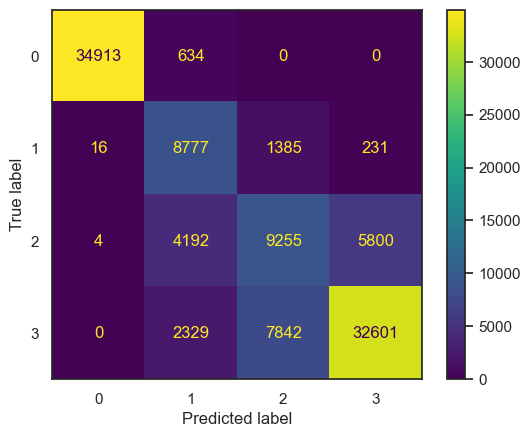

              precision    recall  f1-score   support

           0     0.9994    0.9822    0.9907     35547
           1     0.5509    0.8432    0.6664     10409
           2     0.5008    0.4808    0.4906     19251
           3     0.8439    0.7622    0.8010     42772

    accuracy                         0.7922    107979
   macro avg     0.7237    0.7671    0.7372    107979
weighted avg     0.8057    0.7922    0.7951    107979

Class PR AUC: [[0.9999198291520452, 0.7261370979056011, 0.4870848231645564, 0.8918564449349937]]
Mac PR AUC: ([0.7762495487892991])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2503, 9, 1)
Total subjects: 248
Shape of first subject data: (2503,)
Alpha weights: [0.55399007 1.9295753  1.043602   0.47283244]


2026-03-04 20:50:43.976510: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3427 [..............................] - ETA: 13:01

2026-03-04 20:57:51.057678: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3427/3427 [==============================] - 8s 2ms/step


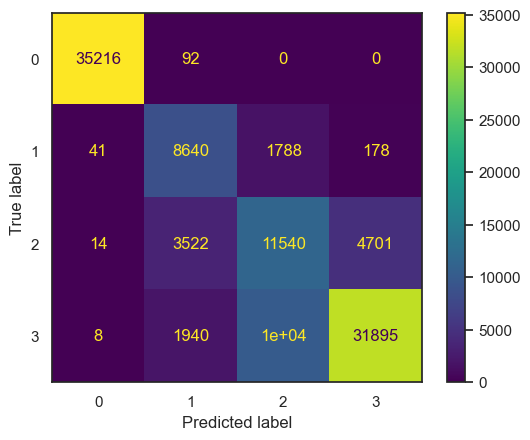

              precision    recall  f1-score   support

           0     0.9982    0.9974    0.9978     35308
           1     0.6087    0.8115    0.6956     10647
           2     0.4928    0.5835    0.5343     19777
           3     0.8673    0.7260    0.7904     43932

    accuracy                         0.7960    109664
   macro avg     0.7418    0.7796    0.7545    109664
weighted avg     0.8168    0.7960    0.8018    109664

Class PR AUC: [[0.9999198291520452, 0.7261370979056011, 0.4870848231645564, 0.8918564449349937], [0.9999519473056855, 0.739009912178587, 0.48246071623312203, 0.8996666275714249]]
Mac PR AUC: ([0.7762495487892991, 0.7802723008222048])
Splitting data for age group 0...
Splitting data for age group 1...
Splitting data for age group 2...
Splitting data for age group 3...
Total subjects: 248
Shape of first subject data: (2503, 9, 1)
Total subjects: 248
Shape of first subject data: (2503,)
Alpha weights: [0.55664766 1.9300201  1.0421257  0.47120643]


2026-03-04 20:58:02.254435: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   1/3290 [..............................] - ETA: 12:00

2026-03-04 21:05:38.057518: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3290/3290 [==============================] - 8s 2ms/step


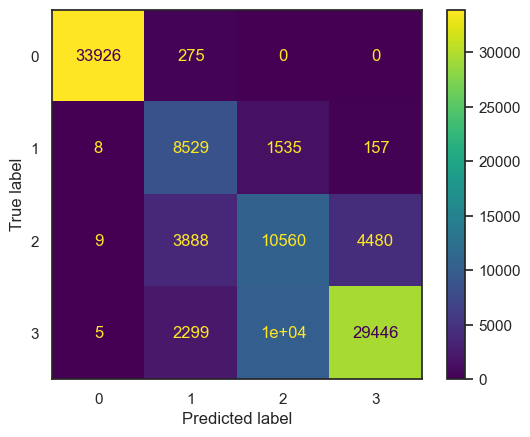

              precision    recall  f1-score   support

           0     0.9994    0.9920    0.9956     34201
           1     0.5689    0.8338    0.6764     10229
           2     0.4748    0.5576    0.5129     18937
           3     0.8639    0.7029    0.7751     41895

    accuracy                         0.7834    105262
   macro avg     0.7268    0.7716    0.7400    105262
weighted avg     0.8093    0.7834    0.7900    105262

Class PR AUC: [[0.9999198291520452, 0.7261370979056011, 0.4870848231645564, 0.8918564449349937], [0.9999519473056855, 0.739009912178587, 0.48246071623312203, 0.8996666275714249], [0.9999847402113251, 0.7313403480622398, 0.4639679421745965, 0.8918822937974744]]
Mac PR AUC: ([0.7762495487892991, 0.7802723008222048, 0.771793831061409])


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


PR_AUC_Mac = []
PR_AUC_class = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []
F1_class = []
Rec_class = []
Pre_class = []

results = {}

for age, group_df in df_scaled.items():
    print(f"Processing age group {age}...")
    X_data, Y_data = data_preprocessing.create_X_Y(group_df, feature="PtID", labels = "Class1", sample_count=9, hours=2, modus="h")
    results[age] = (X_data, Y_data)


for i in [42, 0, 1234]:
    average_precisions = []
    PRauc_scores = []

    X_train_fold, Y_train_fold, X_test_fold, Y_test_fold  = data_initialization(results, 9, i)

    Y_train_encoded = to_categorical(Y_train_fold)
    Y_test_encoded = to_categorical(Y_test_fold)

    # for class weights 
    Y_train_weights = Y_train_fold.reshape(-1).astype("int32")

    # reshapes Y_train, val, and test
    Y_train_rs = Y_train_fold.reshape(-1).astype("int32")
    Y_test_rs = Y_test_fold.reshape(-1).astype("int32")

    # converts train, val, and test data into tensors
    X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
    Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

    X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
    Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

    BUFFER_SIZE = len(X_train_fold) 
    BATCH_SIZE = 128

    # shuffles train data and applies batch size 
    train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
    train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
    class_counts = np.bincount(Y_train_weights, minlength=4).astype(np.float32)
    inv_freq = 1.0 / np.maximum(class_counts, 1)
    alpha = inv_freq / np.mean(inv_freq)  # normalize mean≈1
    print("Alpha weights:", alpha)

    # Define focal loss with tuned alpha and gamma
    focloss = tf.keras.losses.CategoricalFocalCrossentropy(
        gamma=1.5,          # focus more on hard examples
        alpha=alpha,        # per-class weights
        )

    # builds and trains the FCN model
    model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 4) 
    model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=["categorical_accuracy"])
    model_fcn.fit(train_ds, epochs=20, verbose=0)

    sns.set_theme(style="white")
    # evaluates the model and plots the confusion matrix
    predictions_fcn = model_fcn.predict(X_test_t)
    y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
    y_true_labels = np.argmax(Y_test_t, axis=1)
    ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
    plt.show()

    report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
    print(report_fcn)

    f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average="macro")
    F1_macro.append(f1_score_mac)

    rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average="macro")
    Rec_macro.append(rec_scores_mac)

    pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average="macro")
    Pre_macro.append(pre_scores_mac)

    f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    F1_class.append(f1_scores)

    rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(4))
    Rec_class.append(rec_scores)

    pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(4))
    Pre_class.append(pre_scores)

    classes = set(Y_test_rs)
    for n_cl, cl in enumerate(classes):  
            f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
            sorted_indices = np.argsort(f_rec)
            pr_auc_scores = auc(f_rec, f_pre)
            PRauc_scores.append(pr_auc_scores)

    PR_AUC_class.append(PRauc_scores)
    PRAUC_mean = np.mean(PRauc_scores)
    PR_AUC_Mac.append(PRAUC_mean)

    print(f"Class PR AUC: {PR_AUC_class}")
    print(f"Mac PR AUC: ({PR_AUC_Mac})")


# report
with open("Ablations/15_min_Ablation_Class1_120min.txt", "w") as f:

    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")

    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

## Metrics

In [19]:
files = ["Ablations/15_min_Ablation_Class1_30min.txt", 
         "Ablations/15_min_Ablation_Class1_45min.txt", 
         "Ablations/15_min_Ablation_Class1_60min.txt",
         "Ablations/15_min_Ablation_Class1_90min.txt",
         "Ablations/15_min_Ablation_Class1_120min.txt" ]

# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

for file in files: 
    with open(file, "r") as f:
        text = f.read()

    for metric_name, pattern in patterns.items():
        match = re.search(pattern, text)
        if not match:
            continue
        arrays = extract_arrays(match.group(1))
        if arrays.size == 0:
            continue

        if metric_name == "F1 Measure":
            f1_all = arrays
        elif metric_name == "Recall":
            recall_all = arrays
        elif metric_name == "Precision":
            precision_all = arrays
        elif metric_name == "PR AUC":
            pr_auc_all = arrays

    # computes summary stats
    def summarize(metric, name):
        if metric.size == 0:
            print(f"\n{name}: No data found.")
            return
        mean_per_class = np.mean(metric, axis=0)
        std_per_class = np.std(metric, axis=0)
        macro_mean = np.mean(mean_per_class)
        macro_std = np.std(mean_per_class)

        print(f"\n{name} Results:")
        print(f"Mean per Class: {np.round(mean_per_class, 4)}")
        print(f"Std per Class:  {np.round(std_per_class, 4)}")
        print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")
        

    # summarizes all metrics
    summarize(f1_all, "F1 Measure")
    summarize(recall_all, "Recall")
    summarize(precision_all, "Precision")
    summarize(pr_auc_all, "PR AUC")
    print("--------------------")


F1 Measure Results:
Mean per Class: [0.9698 0.6317 0.5192 0.7691]
Std per Class:  [0.0071 0.0018 0.0194 0.0032]
Macro Mean: 0.7225, Macro Std: 0.1680

Recall Results:
Mean per Class: [0.9552 0.7742 0.5878 0.6914]
Std per Class:  [0.0321 0.0223 0.0464 0.0073]
Macro Mean: 0.7522, Macro Std: 0.1345

Precision Results:
Mean per Class: [0.9863 0.5339 0.4661 0.8668]
Std per Class:  [0.0194 0.0085 0.0049 0.0076]
Macro Mean: 0.7133, Macro Std: 0.2187

PR AUC Results:
Mean per Class: [1.     0.6757 0.4654 0.8908]
Std per Class:  [0.     0.0292 0.0126 0.0039]
Macro Mean: 0.7580, Macro Std: 0.2053
--------------------

F1 Measure Results:
Mean per Class: [0.9709 0.6321 0.5085 0.79  ]
Std per Class:  [0.0083 0.003  0.0158 0.0111]
Macro Mean: 0.7254, Macro Std: 0.1734

Recall Results:
Mean per Class: [0.955  0.7998 0.5288 0.7355]
Std per Class:  [0.0319 0.021  0.0142 0.0211]
Macro Mean: 0.7548, Macro Std: 0.1529

Precision Results:
Mean per Class: [0.9886 0.5231 0.4896 0.8537]
Std per Class:  [0.0